# Разработка A/B-тестирования и анализ результатов

## Описание данных

Предстоит работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-11 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц похожая структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Задача: 
Рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными 

#### 1.1. Загрузка исторических данных

- Импортируем библиотеки

- Загружаем датафрейм

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

from math import ceil

import numpy as np

from scipy.stats import ttest_ind

from statsmodels.stats.proportion import proportions_ztest


In [2]:
df_sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')

In [3]:
df_sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитаем количество уникальных сессий `session_id`.

- Выведем на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. 

- Изучим таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.



In [4]:
user_max = df_sessions_history['user_id'].value_counts().idxmax()

display(user_max)

'10E0DEFC1ABDBBE0'

In [5]:
df_user = df_sessions_history[df_sessions_history['user_id'] == '6A73CB5566BB494D']

In [6]:
df_user

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
124515,6A73CB5566BB494D,110E3F28C1F5415F,2025-08-28,2025-08-28 18:58:19,2025-08-28,1,0,3,MENA,Mac
196252,6A73CB5566BB494D,D68C8D98A0F1C439,2025-08-29,2025-08-29 20:53:27,2025-08-28,2,1,3,MENA,Mac
242428,6A73CB5566BB494D,6587D217472BF807,2025-08-30,2025-08-30 13:08:22,2025-08-28,3,1,1,MENA,Mac
304287,6A73CB5566BB494D,A9BC25593D056F8E,2025-09-01,2025-09-01 18:52:49,2025-08-28,4,1,2,MENA,Mac
346611,6A73CB5566BB494D,CB6F9C4191FAF6F6,2025-09-03,2025-09-03 22:49:08,2025-08-28,5,1,3,MENA,Mac
363510,6A73CB5566BB494D,9C609432F6E6535A,2025-09-04,2025-09-04 13:59:46,2025-08-28,6,1,4,MENA,Mac
391902,6A73CB5566BB494D,5D892E33B97A257A,2025-09-06,2025-09-06 18:46:55,2025-08-28,7,1,2,MENA,Mac
404322,6A73CB5566BB494D,22A9BD3861F49087,2025-09-07,2025-09-07 18:33:49,2025-08-28,8,1,3,MENA,Mac
415489,6A73CB5566BB494D,F70E351154B092DC,2025-09-08,2025-09-08 20:30:22,2025-08-28,9,1,4,MENA,Mac
425805,6A73CB5566BB494D,84A3DC0CFF449F53,2025-09-09,2025-09-09 16:36:04,2025-08-28,10,1,1,MENA,Mac


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Визуализируем, как менялось число регистраций в приложении за время его существования.

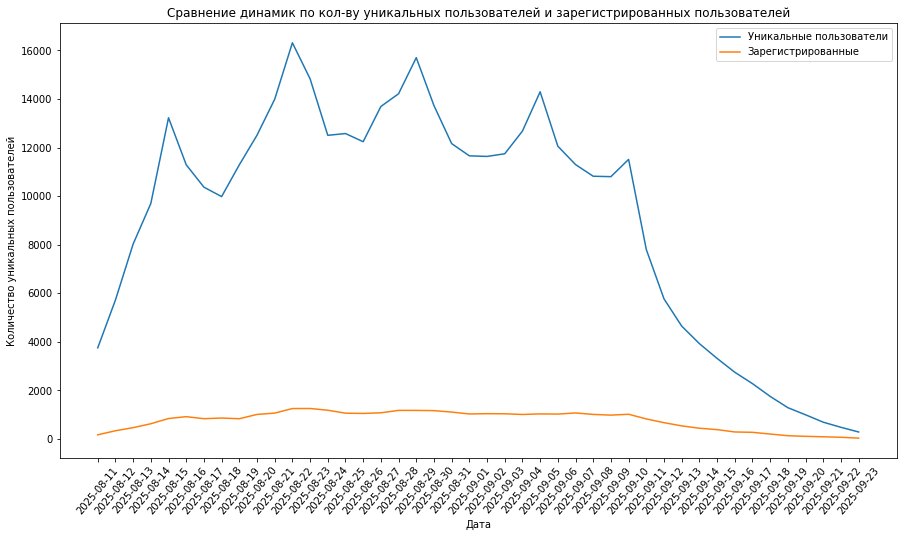

In [7]:
df_grp = (df_sessions_history.groupby(['registration_flag', 'session_date']).agg(
                                        unique_users = ('user_id', 'nunique')
).reset_index()
)


x = df_grp.session_date.unique()
y_a = df_grp[df_grp.registration_flag==0].unique_users
y_b = df_grp[df_grp.registration_flag==1].unique_users

plt.figure(figsize=(15, 8))
plt.plot(x, y_a,label='Уникальные пользователи')
plt.plot(x, y_b, label='Зарегистрированные')

plt.xlabel("Дата")
plt.ylabel("Количество уникальных пользователей")
plt.legend()
plt.title('Сравнение динамик по кол-ву уникальных пользователей и зарегистрированных пользователей')

plt.xticks(rotation=50)

plt.show()

На графике видно, что зарегестрированных пользователей гораздо меньше, чем обычных посетителей без регистрации. Плюс, стоит отметить всплески посетителей приложения в определенные дни и относительно стабильное кол-во регистрировавшихся пользователей. Это могут быть результаты рекламы или повышенный интерес к приложению в определенные дни недели, так как интервал между всплесками около недели. 
Под конец показатели посетителей и зарегистрированных пользователей сходятся по кол-ву. Возможно, первые несколько недель на графике - это первые недели после запуска приложения, этим может быть обусловлен повышенный интерес, а далее показатели стабилизируются, тк остаются заинтересованные в продукте пользователи.

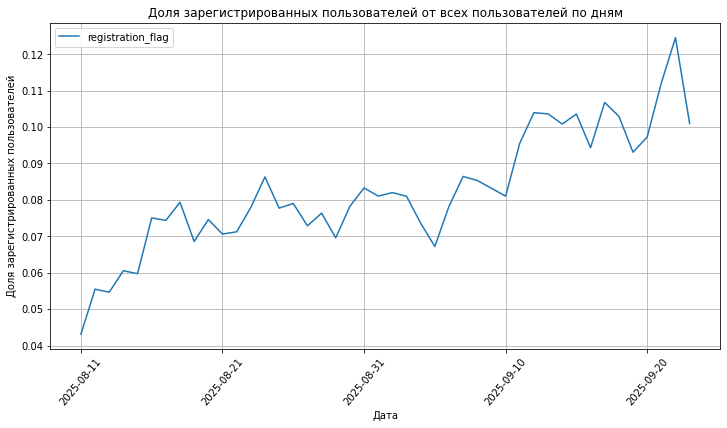

In [8]:
grouped = df_sessions_history.groupby('session_date')['registration_flag'].mean()
grouped.plot(kind='line',
             title='Доля зарегистрированных пользователей от всех пользователей по дням',
             legend=True,
             ylabel='Доля зарегистрированных пользователей',
             xlabel='Дата',
             rot=50,
             figsize=(12, 6))
plt.grid()

plt.show()

Можно заметить, что доля зарегистрированных пользователей за полтора месяца выросла с ~4,5% до 10%. Можно предположить, что скачки регистраций на графике - это результат проводимых акций и выгодных предложений.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

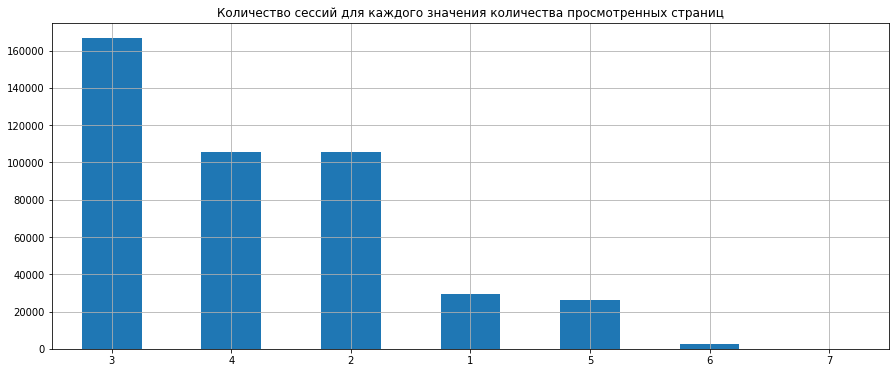

In [9]:
df_sessions_history['page_counter'].value_counts().plot(kind='bar',
                                                        title='Количество сессий для каждого значения количества просмотренных страниц',
                                                        rot=0, 
                                                        legend=False,
                                                        figsize=(15, 6))   

plt.grid()

plt.show()

На графике заметно, что наиболее частым кол-вом просмотренных страниц за одну сессию являются 3 страницы. На втором и третьем местах идут 4 и 2 страницы за сессию. Показатели неплохие, так как команда приложения 4 страницы за сессию считает успешной сессией, и такие сессии по частоте аж на втором месте. 

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

In [10]:
df_sessions_history['good_session'] = df_sessions_history['page_counter'] >=4

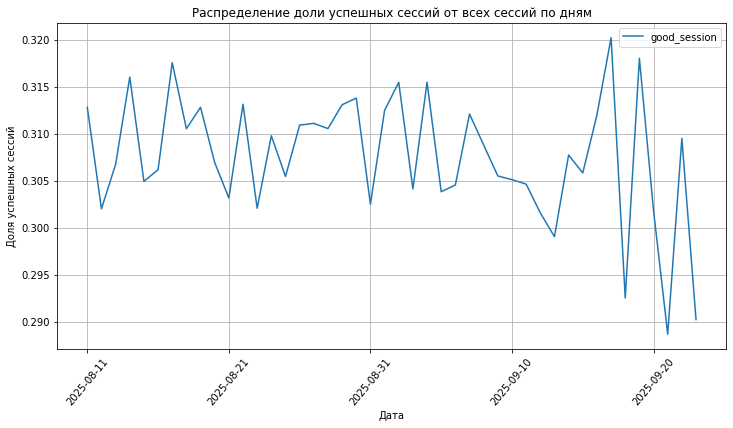

In [11]:
grouped2 = df_sessions_history.groupby('session_date')['good_session'].mean()
grouped2.plot(kind='line',
              title='Распределение доли успешных сессий от всех сессий по дням',
              legend=True,
              ylabel='Доля успешных сессий',
              xlabel='Дата',
              rot=50,
              figsize=(12, 6))
plt.grid()

plt.show()

С помощью графика можно заметить, что показатель "Доля успешных сессий от всех сессий по дням" нестабилен. Особенно это выражено на правой части графика, а это значит, что показатель со временем стал более нестабильным и доля успешных сессий в конечном итоге стала меньше, чем полтора месяца ранее. 

### 2. Подготовка к тесту

- Сформулируем нулевую и альтернативную гипотезы

- Определимся с целевой метрикой.

- Рассчитаем необходимый размер выборки.

- Исходя из текущих значений трафика рассчитаем необходимую длительность проведения теста.

#### 2.1 Формулировка нулевой и альтернативной гипотез

Целевая метрика - "Средняя продолжительность сессии на одного пользователя". Необходимо сравнить средние продолжительности сессий пользователей до введения нового алгоритма и после. 

- Нулевая гипотеза(H0): Средняя продолжительность сессии (μ) одинакова в группе А и в группе В.
- Альтернативная гипотеза (H1): Средняя продолжительность сессии (μ) в группе В выше, чем в группе А.

- Н0 : μA = μB
- Н1 : μA < μB

#### 2.2. Расчёт размера выборки

In [12]:
# Задаём параметры
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 0.8  # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Рассчитываем размер выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


Для проведения теста необходимо 41040 пользователей. То есть по 20520 пользователей на группу.

#### 2.3. Расчёт длительности A/B-теста

- Рассчитаем среднее количество уникальных пользователей приложения в день.

- Определим длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлим в большую сторону.

In [13]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = df_sessions_history.groupby('session_date')['user_id'].nunique().mean()

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(2 * 41040 / avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 9 дней


Таким образом, на проведение теста понадобится 9 дней.

### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Сохраним в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитаем количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитаем и выведим на экран процентную разницу в количестве пользователей в группах A и B. Пострим визуализацию, на которой будет видно возможное различие двух групп.

In [14]:
df_sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv') 

In [15]:
diff = df_sessions_test_part.groupby(['test_group', 'session_date'])['user_id'].nunique()

diff

test_group  session_date
A           2025-10-14      1477
B           2025-10-14      1466
Name: user_id, dtype: int64

In [16]:
diff_AB = round(100 * ((1477 - 1466) / 1477),2)

diff_AB

0.74

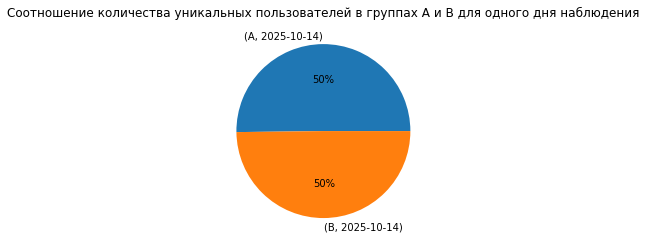

In [17]:
diff.plot(kind='pie',
          legend=False,
          title='Соотношение количества уникальных пользователей в группах А и В для одного дня наблюдения',
          autopct='%.0f%%',
          ylabel='')

plt.show()

Как можно заметить из расчетов и визуализации, разница в количестве пользователей незначительна и составляет всего 0.74%

#### 3.2. Проверка пересечений пользователей

Рассчитаем количество пользователей, которые встречаются одновременно в группах A и B.

In [18]:
df_sessions_test_part

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,3404844B53442747,B4901323BD537E45,2025-10-14,2025-10-14 19:28:49,2025-10-14,1,0,3,CIS,Android,B
1,3A2BF4D364E62D89,216FC619308F8788,2025-10-14,2025-10-14 21:11:04,2025-10-14,1,0,3,MENA,iPhone,A
2,79CDAE11E32B1597,EDFCE4AC1A504074,2025-10-14,2025-10-14 21:44:03,2025-10-14,1,0,3,CIS,iPhone,A
3,D6AF8D78297A931F,CF0AC0EEDE92C690,2025-10-14,2025-10-14 19:07:55,2025-10-14,1,0,4,CIS,PC,A
4,37E0CE723AE568E0,2E6ED45E8C86C4E9,2025-10-14,2025-10-14 15:39:44,2025-10-14,1,0,3,CIS,Mac,B
...,...,...,...,...,...,...,...,...,...,...,...
3125,02A3BA5F727BC3C9,7D4427384463A16E,2025-10-14,2025-10-14 14:52:26,2025-10-14,1,0,4,MENA,Android,B
3126,A7E51F39427F03A5,290910138655DD03,2025-10-14,2025-10-14 19:15:18,2025-10-14,1,0,2,CIS,PC,B
3127,78DDBD077D61EEDB,C10E073BFF1FAF0C,2025-10-14,2025-10-14 16:07:20,2025-10-14,1,0,2,EU,iPhone,B
3128,B44E0A30E8ED1AFC,7B404F7021711E5D,2025-10-14,2025-10-14 17:41:01,2025-10-14,1,0,3,EU,Mac,B


In [19]:
df_sessions_test_part['test_group'].unique() 

array(['B', 'A'], dtype=object)

In [20]:
a = df_sessions_test_part[df_sessions_test_part['test_group'] == 'A']['user_id']
b = df_sessions_test_part[df_sessions_test_part['test_group'] == 'B']['user_id']

intersection = list(set(a) & set(b))
print(intersection) 

[]


Пользователей, которые встречаются одновременно в группах A и B, не замечено.

#### 3.3. Равномерность разделения пользователей по устройствам
Убедимся, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Построем две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

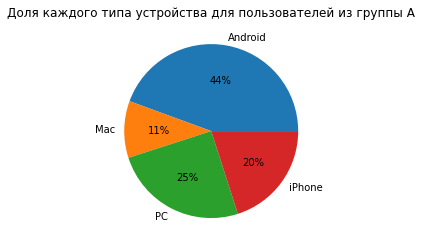

In [21]:
df_sessions_test_part[df_sessions_test_part['test_group'] == 'A'].groupby('device')['user_id'].nunique().plot(
    kind='pie',
    title='Доля каждого типа устройства для пользователей из группы A',
    autopct='%.0f%%',
    ylabel=''
)

plt.show()

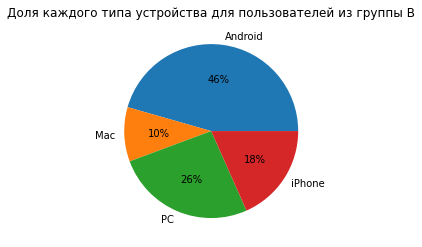

In [22]:
df_sessions_test_part[df_sessions_test_part['test_group'] == 'B'].groupby('device')['user_id'].nunique().plot(
    kind='pie',
    title='Доля каждого типа устройства для пользователей из группы B',
    autopct='%.0f%%',
    ylabel=''
)

plt.show()

Доля каждого типа устройства для пользователей обеих групп практически идентична.

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.

Построим две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

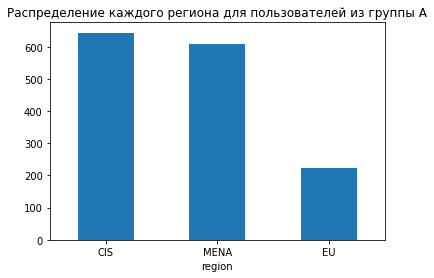

In [23]:
df_sessions_test_part[df_sessions_test_part['test_group'] == 'A'].groupby('region')['user_id'].nunique().sort_values(ascending=False).plot(
    kind='bar',
    title='Распределение каждого региона для пользователей из группы A',
    rot=0
)

plt.show()

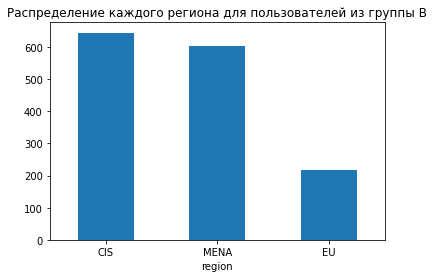

In [24]:
df_sessions_test_part[df_sessions_test_part['test_group'] == 'B'].groupby('region')['user_id'].nunique().sort_values(ascending=False).plot(
    kind='bar',
    title='Распределение каждого региона для пользователей из группы B',
    rot=0
)

plt.show()

Распределение регионов идентично. Так, в обоих группах преобладает регион "CIS", на втором месте "MENA" и на третьем "EU".

#### 3.5. Вывод после проверки A/B-теста

В ходе анализа A/B теста были выявлены следующие особенности:
- Как можно заметить из расчетов и визуализаций, разница в количестве пользователей незначительна и составляет всего 0.74%;
- Выборки являются независимыми, так как пересечений пользователей из тестовой и контрольной групп не замечено;
- Доля каждого типа устройства для пользователей обеих групп практически идентична. Однако, распределение регионов не равномерно. В группе А на первом месте по популярности регион "CIS", а в группе В - "MENA".

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у нас есть результаты за все дни проведения эксперимента. 

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Сохраним в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создадим дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [25]:
df_sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')

In [26]:
df_sessions_test.head(1)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A


In [27]:
df_sessions_test['good_session'] = df_sessions_test['page_counter'] >= 4

In [28]:
df_sessions_test['good_session']

0         False
1         False
2         False
3         False
4         False
          ...  
100000    False
100001     True
100002    False
100003     True
100004    False
Name: good_session, Length: 100005, dtype: bool

#### 4.2. Проверка корректности результатов теста

Необходимо убедиться, что тест проведён корректно.

- Рассчитаем количество уникальных сессий для каждого дня и обеих тестовых групп.

- Проверим, что количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми. Используйте статистический тест.

- В качестве ответа выведим на экран полученное значение p-value и интерпретируем его.

In [29]:
unique_sessions1 = df_sessions_test.groupby(['test_group', 'session_date']).agg({'session_id': 'nunique'}).reset_index()

unique_sessions1

,test_group,session_date,session_id
0,A,2025-10-14,1502
1,A,2025-10-15,2235
2,A,2025-10-16,3280
3,A,2025-10-17,4089
4,A,2025-10-18,5013
5,A,2025-10-19,6535
6,A,2025-10-20,5837
7,A,2025-10-21,3927
8,A,2025-10-22,3083
9,A,2025-10-23,2470


In [30]:
unique_sessions = pd.pivot_table(df_sessions_test,
                                 index='session_date',
                                 columns='test_group',
                                 values='session_id',
                                 aggfunc=['nunique'])

display(unique_sessions)

nunique      
test_group         A     B
session_date              
2025-10-14      1502  1628
2025-10-15      2235  2283
2025-10-16      3280  3241
2025-10-17      4089  4054
2025-10-18      5013  5059
2025-10-19      6535  6779
2025-10-20      5837  6089
2025-10-21      3927  3981
2025-10-22      3083  3111
2025-10-23      2470  2548
2025-10-24      2090  2068
2025-10-25      1897  1814
2025-10-26      1669  1692
2025-10-27      1454  1517
2025-10-28      1279  1289
2025-10-29      1068  1131
2025-10-30       887   876
2025-10-31       644   669
2025-11-01       434   465
2025-11-02       158   160

In [31]:
metrics = unique_sessions1.set_index('test_group').groupby('test_group').agg({'session_id': np.mean}).T

metrics 

test_group,A,B
session_id,2477.55,2522.7


In [32]:
sample_a = unique_sessions1[unique_sessions1['test_group']=='A']['session_id']

sample_b = unique_sessions1[unique_sessions1['test_group']=='B']['session_id']

test_result = ttest_ind(
    sample_a,
    sample_b,
    alternative='two-sided' 
)

alpha = 0.05

if test_result.pvalue > alpha:
    print(f'pvalue={test_result.pvalue} > {alpha}')
    print('Не получилось отвергнуть нулевую гипотезу')
else:
    print(f'pvalue={test_result.pvalue} < {alpha}')
    print('Отвергаем нулевую гипотезу') 

pvalue=0.938219304859116 > 0.05
Не получилось отвергнуть нулевую гипотезу


Количество уникальных дневных сессий в двух выборках не различается или различия не статистически значимыми.

#### 4.3. Сравнение доли успешных сессий

Переходим к анализу ключевой метрики — доли успешных сессий.

Рассчитаем долю успешных сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразим на экране.

In [33]:
part_good_session_A,part_good_session_B = df_sessions_test[df_sessions_test['test_group']=='A']['good_session'].mean(), df_sessions_test[df_sessions_test['test_group']=='B']['good_session'].mean()

diff = round(part_good_session_B - part_good_session_A,4)

part_good_session_A, part_good_session_B, diff 

(0.3077233557344958, 0.31828992745867524, 0.0106)

Разница показателей состовляет всего 1.1% процент.

#### 4.4. Насколько статистически значимо изменение ключевой метрики

- Используя статистический тест, рассчитаем, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведем на экран полученное значение p-value и свои выводы о статистической значимости.

In [34]:
n_a, n_b = df_sessions_test[df_sessions_test.test_group=='A'].shape[0], df_sessions_test[df_sessions_test.test_group=='B'].shape[0]
m_a = df_sessions_test[df_sessions_test['test_group']=='A']['good_session'].sum()
m_b = df_sessions_test[df_sessions_test['test_group']=='B']['good_session'].sum()

alpha = 0.05 

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='two-sided'
)
p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.0003149479976072246 < 0.05
Нулевая гипотеза не находит подтверждения!


С помощью Z-теста были получены следуюшие результаты: 
p-value меньше уровня значимости, поэтому нет оснований принимать нулевую гипотезу. Альтернативная гипотеза находит подтверждение. Поэтому, можно сделать вывод, что существует статистически значимое различие между количеством успешных сессий в выборках А и В. 

Таким образом, альтернативня гипотеза о том, что новый алгоритм бесконечной ленты повысит долю успешных сессий, оказалась верной. 

#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведенного анализа результатов теста можно сформулировать следующие выводы:
- В эксперименте было задействовано 41040 пользователей, по 20520 пользователей на группу. Учитывая среднее кол-во посещений пользователями приложения в день, длительность эксперимента составила 9 дней. Пользователи в группах соотносились по количеству и не пересекались, поэтому эксперимент можно считать чистым; 
- Внедрение нового алгоритма рекомендаций повлияло на рост доли успешных сессий. Прирост составил 1.1%, что оказалось статистически значимым результатом;
- Значение p-value для оценки статистической значимости выявленного эффекта получилось 0.0003149479976072246, что сильно меньше уровня значимости 0.05, поэтому нулевая гипотеза не подтвердилась;
- На основе полученных данных можно сказать, что новый бесконечный алгоритм полезен и его внедрение повысит долю успешных сессий.